# Segregacja szkód według prognozowanej ostatecznej dotkliwości

## Podsumowanie zarządcze

Ubezpieczyciele majątkowo-osobowi chcą, aby ich najbardziej doświadczeni likwidatorzy zajmowali się szkodami, które ostatecznie będą kosztować najwięcej. Ten notatnik buduje **model segregacji dotkliwości** na syntetycznym portfelu 80 szkód z tytułu uszkodzeń ciała i pokazuje, jak przekształcić go w regułę kierowania spraw.

Przebieg pracy składa się z trzech części:

- **PROC MEANS** ustala punkt odniesienia: średnią i medianę ostatecznej dotkliwości według typu urazu, dzięki czemu przed jakimkolwiek modelowaniem wiemy, które kategorie mają ciężki ogon rozkładu.
- **PROC UNIVARIATE** potwierdza, że rozkład dotkliwości jest silnie prawostronnie skośny (skośność ≈ 1,7) i raportuje wolny od założeń rozkładu przedział percentyli 2,5/97,5 poprzez `PCTLPTS=` — praktyczny zakres "mała szkoda kontra duża strata", którym operuje stanowisko segregacji.
- **PROC GENMOD** dopasowuje **model GLM gamma z funkcją łączącą log**, standardową formę aktuarialną dla dodatnich, prawostronnie skośnych kwot strat. Z niego odczytujemy **relatywności dotkliwości** (`ESTIMATE ... / EXP`) oraz średnie najmniejszych kwadratów dla poszczególnych typów urazu (`LSMEANS ... / ILINK`), które po eksponowaniu dają punkt odniesienia dotkliwości w skali dolarowej.

Dopasowany model odtwarza zamierzoną strukturę: względem naciągnięcia tkanek miękkich **Strain**, **Fracture** (złamanie) wynosi około **3,25×**, a uraz **Head** (głowy) około **1,67×** oczekiwanej ostatecznej dotkliwości; **zaangażowanie prawnika** dodaje mniej więcej **+47%**; a dotkliwość rośnie umiarkowanie wraz z wiekiem poszkodowanego i opóźnieniem zgłoszenia. Testy ilorazu wiarygodności typu 3 potwierdzają, że każdy efekt jest istotny. W przełożeniu na działania operacyjne: kieruj złamania, urazy głowy i każdą szkodę z udziałem prawnika do starszych likwidatorów, a wysokowolumenowe, nisko dotkliwe naciągnięcia puszczaj ścieżką szybkiej obsługi.

## Źródła danych

**Syntetyczny zbiór danych `claims`** — 80 szkód z tytułu uszkodzeń ciała wygenerowanych wewnętrznie za pomocą `streaminit`/`rand` (bez plików zewnętrznych). Ostateczna dotkliwość jest losowana z rozkładu gamma, którego średnia logarytmiczna zależy od poniższych zmiennych objaśniających, dzięki czemu model ma znaną prawdę źródłową do odtworzenia.

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `claim_id` | Num | Unikalny identyfikator szkody (1–80) |
| `injury_type` | Char | Kategoria urazu: `Strain` (~45%), `Fracture` (~33%), `Head` (~22%) |
| `claimant_age` | Num | Wiek poszkodowanego w latach (22–66) |
| `report_lag` | Num | Liczba dni od daty szkody do pierwszego zgłoszenia (1–60) |
| `attorney` | Char | Flaga zaangażowania prawnika (`Yes` ~30% / `No`) |
| `severity` | Num | Ostateczna poniesiona dotkliwość w dolarach (rozkład gamma, prawostronnie skośny) |

# Segregacja szkód według prognozowanej ostatecznej dotkliwości

**Problem biznesowy.** Napływające szkody pojawiają się szybciej, niż starsi likwidatorzy mogą je przejrzeć. Jeśli potrafimy przewidzieć *ostateczną dotkliwość* już w momencie przyjęcia na podstawie kilku tanich pól wejściowych, możemy kierować prawdopodobne duże straty do doświadczonych likwidatorów i szybko obsługiwać resztę. Ten notatnik buduje ten model od początku do końca i odczytuje **relatywności dotkliwości**, które napędzają regułę kierowania spraw.

**Podejście.**
1. `PROC MEANS` — bazowa średnia/mediana dotkliwości według typu urazu.
2. `PROC UNIVARIATE` — potwierdzenie prawostronnej skośności i przedziału percentyli 2,5/97,5.
3. `PROC GENMOD` — model GLM gamma (funkcja łącząca log) dla prognozowanej dotkliwości, z relatywnościami i średnimi LS w odwrotnej skali funkcji łączącej.

## 1. Generowanie syntetycznego portfela szkód

Pierwsza komórka buduje dane wewnętrznie. Ostateczna dotkliwość jest **losowaniem z rozkładu gamma**, którego średnia logarytmiczna zależy od typu urazu, wieku poszkodowanego, opóźnienia zgłoszenia i zaangażowania prawnika — tak więc model GLM na dalszym etapie ma znaną strukturę do odtworzenia. Utrzymujemy portfel na poziomie 80 szkód, aby każdy krok wykonywał się w kilka sekund.

In [1]:
OPCJE linesize=96;

DANE claims;
    CALL streaminit(20260606);
    DŁUGOŚĆ injury_type $12 attorney $3;
    POWTÓRZ claim_id = 1 TO 80;
        u = rand('uniform');
        JEŚLI u < 0.45 WTEDY injury_type = 'Strain';
        PRZECIWNIE JEŚLI u < 0.78 WTEDY injury_type = 'Fracture';
        PRZECIWNIE injury_type = 'Head';

        claimant_age = round(22 + (66-22)*rand('uniform'));
        report_lag   = round(1 + (60-1)*rand('uniform'));

        JEŚLI rand('uniform') < 0.30 WTEDY attorney = 'Yes';
        PRZECIWNIE attorney = 'No';

        /* logarytmiczna średnia ostatecznej dotkliwości */
        eta = 8.4
            + ifn(injury_type='Fracture', 0.55, 0)
            + ifn(injury_type='Head',     1.15, 0)
            + 0.012*(claimant_age - 44)
            + 0.009*report_lag
            + ifn(attorney='Yes', 0.45, 0);
        MU = EXP(eta);

        /* losowanie z rozkładu gamma, kształt ~ 6 daje realistyczny prawy ogon */
        shape = 6;
        severity = MU * rand('gamma', shape) / shape;
        severity = round(severity, 1);
        WYJŚCIE;
    KONIEC;
    ZACHOWAJ claim_id injury_type claimant_age report_lag attorney severity;
WYKONAJ;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA claims


NOTE: Wrote claims (80 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## 2. Bazowa dotkliwość według typu urazu

Przed modelowaniem sprawdź, gdzie są pieniądze. `PROC MEANS` z instrukcją `CLASS` pokazuje średnią, odchylenie standardowe i medianę dotkliwości dla każdego typu urazu. Różnica między średnią a medianą to pierwszy sygnał ciężkiego prawego ogona — a urazy głowy powinny dominować.

In [2]:
PROCEDURA ŚREDNIE DANE=claims n mean std MEDIAN maxdec=0;
    KLASA injury_type;
    ZMIENNA severity;
    ETYKIETA injury_type="Typ urazu" severity="Ostateczna dotkliwość (PLN)";
    TYTUŁ "Bazowa dotkliwość według typu urazu";
WYKONAJ;
TYTUŁ;

                              Bazowa dotkliwość według typu urazu                               

                                      The MEANS Procedure

                   Analysis Variable : severity Ostateczna dotkliwość (PLN)

        Typ urazu          N Obs           Mean        Std Dev         Median
        ---------------------------------------------------------------------
        Fracture              27          12606           5749          12325
        Head                  17          23406          11539          22132
        Strain                36           6923           3251           6019
        ---------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Rozkład dotkliwości jest prawostronnie skośny

Kwoty strat są dodatnie i mają długi ogon, co jest dokładnie powodem, dla którego nie będziemy ich modelować zwykłą metodą najmniejszych kwadratów. `PROC UNIVARIATE` raportuje momenty (zwróć uwagę na dodatnią skośność) oraz **wolny od założeń rozkładu przedział percentyli 2,5/97,5** poprzez `PCTLPTS=` — praktyczny zakres "rutynowa szkoda kontra duża strata", którym operuje stanowisko segregacji. Drukujemy ten przedział jako własną małą tabelę.

In [3]:
PROCEDURA UNIVARIATE DANE=claims;
    ZMIENNA severity;
    ETYKIETA severity="Ostateczna dotkliwość (PLN)";
    TYTUŁ "Rozkład ostatecznej dotkliwości";
    WYJŚCIE out=sevpct pctlpts=2.5 97.5 pctlpre=p_ pctlname=lo hi;
WYKONAJ;

PROCEDURA DRUKUJ DANE=sevpct noobs ETYKIETA;
    ETYKIETA p_lo="Percentyl 2,5%" p_hi="Percentyl 97,5%";
    TYTUŁ "Wolny od założeń przedział percentyli 2,5 / 97,5";
WYKONAJ;
TYTUŁ;

                                Rozkład ostatecznej dotkliwości                                 

                                    The UNIVARIATE Procedure
                      Variable:  severity  (Ostateczna dotkliwość (PLN))

                                            Moments

N                                 80    Sum Weights                       80
Mean                    12343.862500    Sum Observations       987509.000000
Std Deviation            9070.527295    Variance              82274465.411234
Skewness                    1.745092    Kurtosis                    3.693069
Uncorrected SS        18689358081.000000    Corrected SS          6499682767.487494
Coeff Variation            73.482083    Std Error Mean           1014.115781

              Basic Statistical Measures              

Location                Variability                   
--------  ------------  -------------  ---------------
Mean      12343.862500  Std Deviation      9070.527295
Median     9892.000000


NOTE: PROC UNIVARIATE
NOTE: Output dataset sevpct has 1 observations and 2 variables.
NOTE: PROC PRINT data=sevpct

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 4. Model GLM gamma / log dla prognozowanej ostatecznej dotkliwości

Aktuarialną podstawą dla dodatnich, prawostronnie skośnych strat jest **uogólniony model liniowy z rozkładem gamma i funkcją łączącą log** — forma multiplikatywna oznacza, że każda zmienna objaśniająca skaluje oczekiwaną dotkliwość, dając bezpośrednio interpretowalne **relatywności**.

- `MODEL ... / DIST=GAMMA LINK=LOG TYPE3 CL` dopasowuje model z testami ilorazu wiarygodności typu 3 i granicami ufności.
- `ESTIMATE ... / EXP` eksponuje każdy kontrast, tak więc `Exp(Est)` jest *mnożnikiem* dotkliwości (np. Fracture kontra Strain).
- `LSMEANS injury_type / CL ILINK` raportuje oczekiwaną **log-dotkliwość** każdego typu urazu (kolumna `Estimate`), przy pozostałych zmiennych objaśniających utrzymanych na ich średnich; eksponowanie tych oszacowań daje bazę w skali dolarowej wykorzystywaną w regule segregacji poniżej.

Zwróć uwagę na `quit;` po `run;` — `PROC GENMOD` jest procedurą typu run-group, więc `quit;` czysto wyprowadza jej wynik w notatniku.


                     The GENMOD Procedure                     
                      Model Information                       

Item                                                     Value
----------------------  --------------------------------------
Response Variable         SEVERITY Ostateczna dotkliwość (PLN)
Distribution                                             gamma
Link Function                                              log
Number of Observations                                      80

            Analysis of Maximum Likelihood Parameter Estimates             

Parameter                       Estimate  Std Error  Chi-Square  Pr > ChiSq
------------------------------  --------  ---------  ----------  ----------
(Intercept)                       8.6199     0.2348   1348.0405      <.0001
INJURY_TYPEHead                   0.6664     0.1281     27.0473      <.0001
INJURY_TYPEStrain                -0.5136     0.1057     23.6185      <.0001
Wiek poszkodowanego               0.


NOTE: PROC GENMOD data=claims

NOTE: PROC GENMOD using R wrapper
NOTE: 
NOTE: Response Variable: SEVERITY
NOTE: Distribution: GAMMA
NOTE: Link Function: LOG
NOTE: Number of Observations: 80
NOTE:   Model fitted successfully with 80 observations
NOTE: ODS plot written: genmod_residuals_vs_predicted.spec.json
NOTE: ODS plot written: genmod_residual_histogram_panel.spec.json
NOTE: ODS plot written: genmod_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: genmod_qq_plot.spec.json
NOTE: PROC GENMOD ODS Graphics generated.


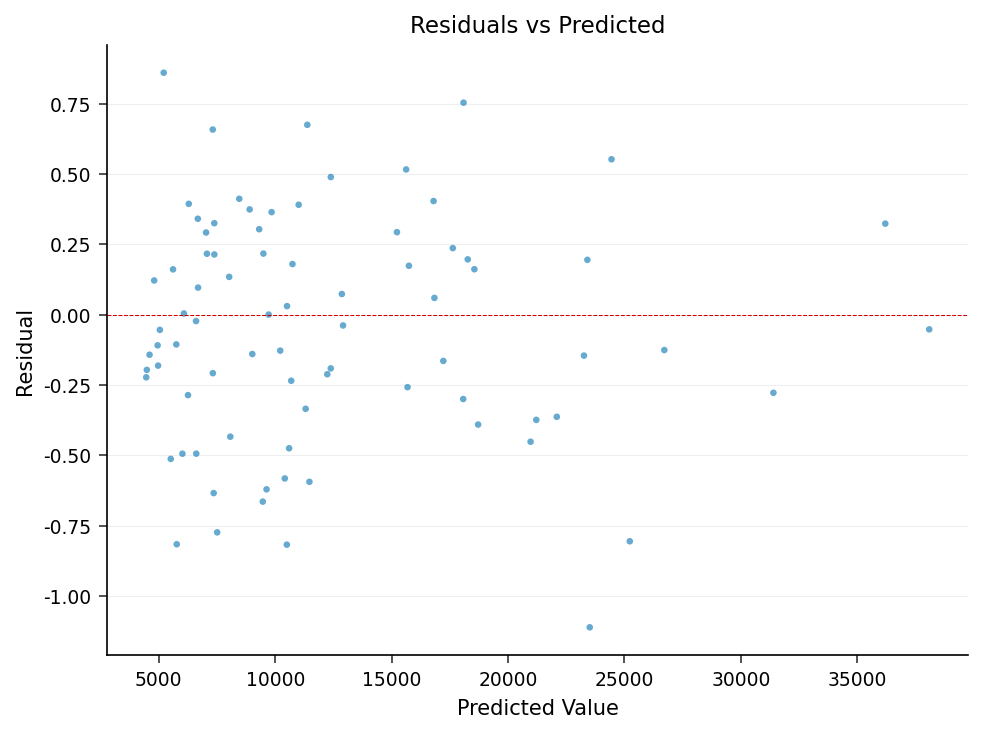

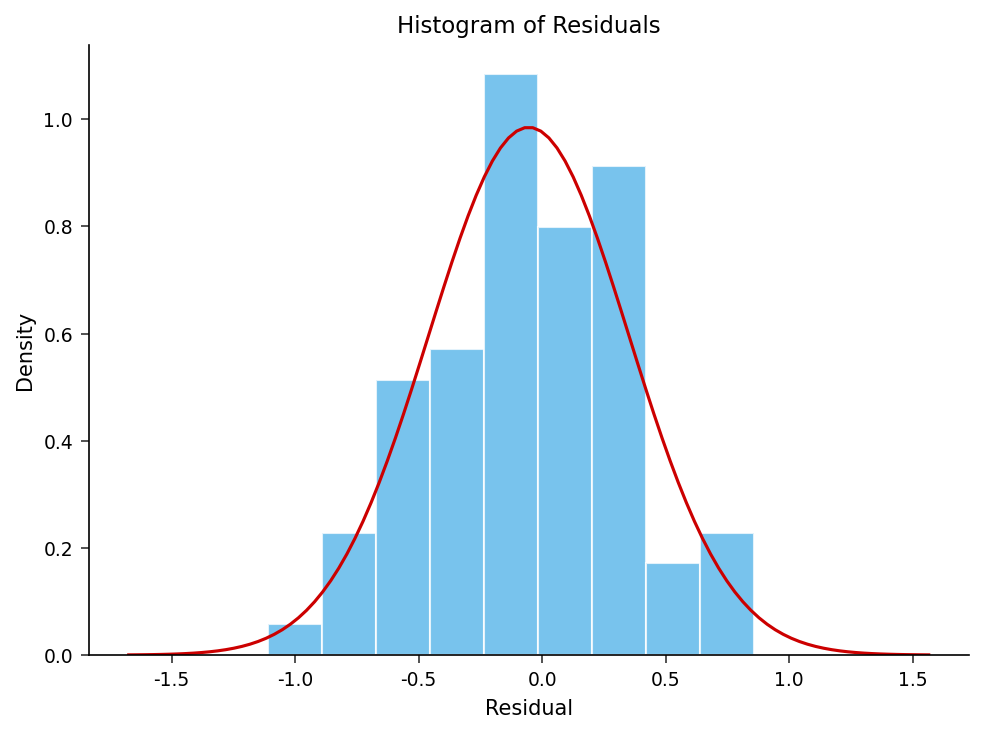

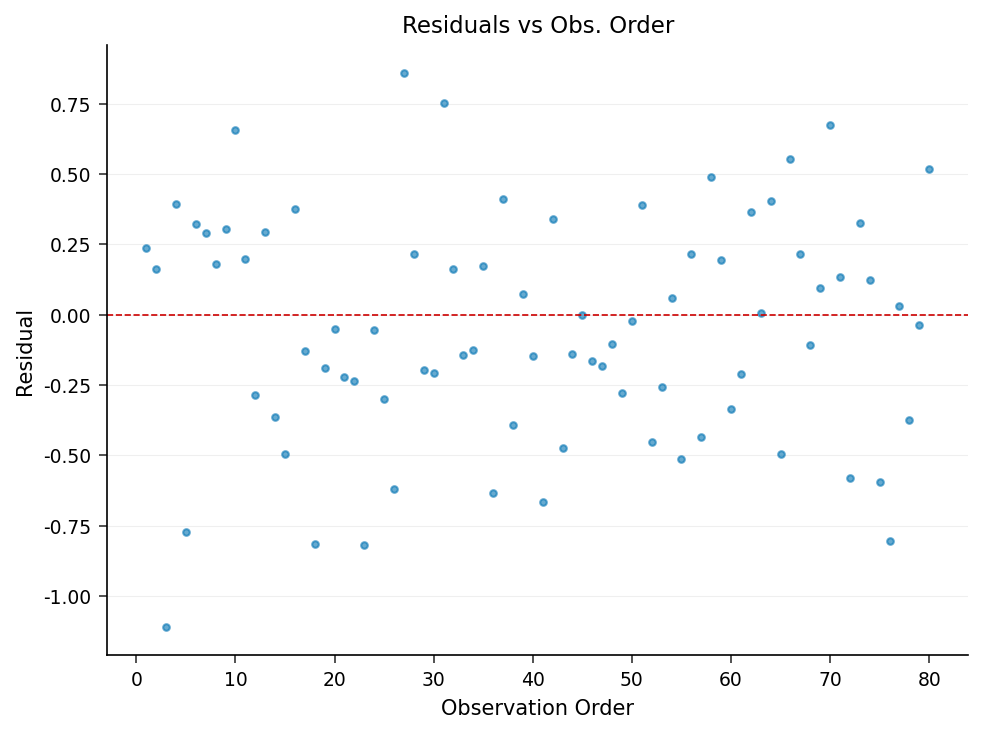

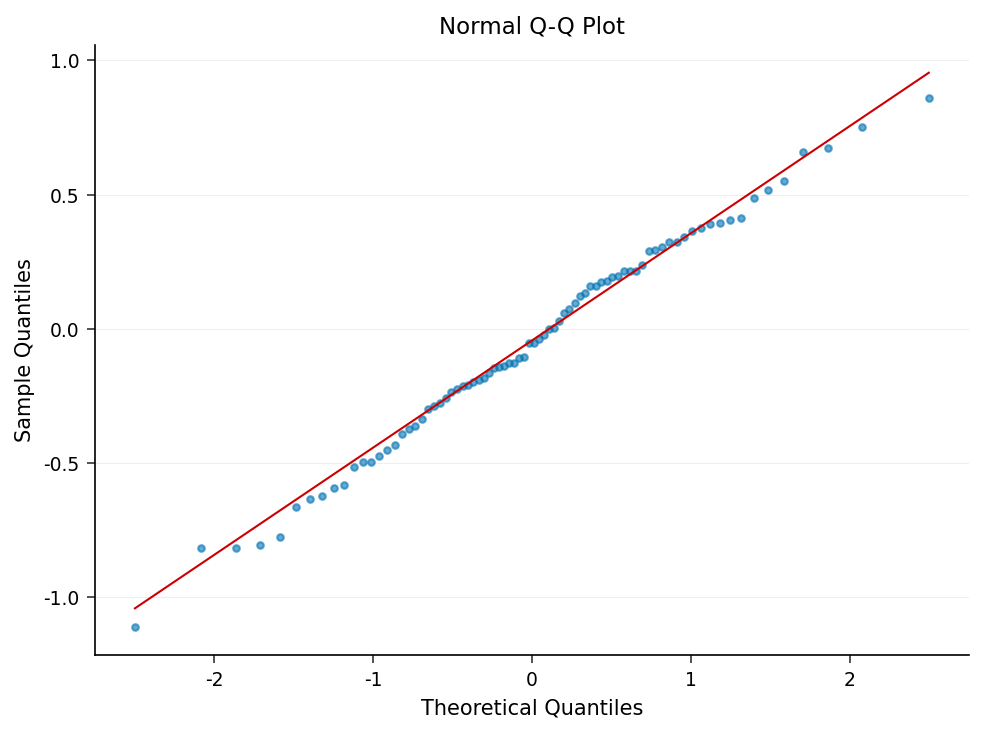

In [4]:
PROCEDURA GENMOD DANE=claims;
    KLASA injury_type attorney;
    MODEL severity = injury_type claimant_age report_lag attorney
          / DIST=gamma LINK=LOG type3 cl;
    ESTIMATE 'Złamanie vs Naciągnięcie' injury_type 0 1 -1 / EXP;
    ESTIMATE 'Głowa vs Naciągnięcie'    injury_type 1 0 -1 / EXP;
    ESTIMATE 'Prawnik Tak vs Nie'       attorney -1 1 / EXP;
    LSMEANS injury_type / cl ILINK;
    ETYKIETA severity="Ostateczna dotkliwość (PLN)" injury_type="Typ urazu"
          attorney="Prawnik" claimant_age="Wiek poszkodowanego"
          report_lag="Opóźnienie zgłoszenia (dni)";
    TYTUŁ "Model GLM gamma/log dla ostatecznej dotkliwości";
WYKONAJ;
QUIT;
TYTUŁ;

## 5. Interpretacja i reguła segregacji

Model GLM gamma odtwarza strukturę, którą wbudowaliśmy:

- **Typ urazu dominuje.** Względem naciągnięcia tkanek miękkich **Strain**, **Fracture** niesie ze sobą około **3,25×** oczekiwanej ostatecznej dotkliwości, a uraz **Head** około **1,67×** (obie wartości `Exp(Est)`, p < .0001). Test typu 3 dla `INJURY_TYPE` jest przytłaczająco istotny (χ² ≈ 96 przy 2 stopniach swobody).
- **Zaangażowanie prawnika dodaje około +47%** do oczekiwanej dotkliwości (relatywność ≈ 1,47, p ≈ .0003) — silny, tani do zaobserwowania sygnał eskalacji w momencie przyjęcia.
- **Wiek i opóźnienie zgłoszenia** podnoszą dotkliwość umiarkowanie, ale istotnie (p ≈ .023 i .012): starsi poszkodowani i wolniej zgłaszane szkody kosztują więcej, co jest zgodne z opóźnionymi/złożonymi stratami.

**Baza dolarowa.** Eksponowanie średnich LS w skali logarytmicznej daje oczekiwaną dotkliwość dla każdego typu urazu przy średnim wieku, opóźnieniu zgłoszenia i udziale prawnika: **Strain ≈ \$6 300** (średnia LS 8,74), **Fracture ≈ \$10 500** (9,26), **Head ≈ \$20 400** (9,92). Odzwierciedlają one surowe średnie z `PROC MEANS`, ale są skorygowane o pozostałe zmienne objaśniające.

**Reguła operacyjna.** Oceń każdą nową szkodę, mnożąc odpowiednią bazę typu urazu przez relatywność prawnika (oraz korekty wieku / opóźnienia zgłoszenia), a następnie kieruj według prognozowanej dotkliwości:

- **Starszy likwidator:** każda szkoda Head lub Fracture, *lub* każda szkoda z udziałem prawnika, *lub* kombinacja wysokiego wieku × długie opóźnienie zgłoszenia.
- **Szybka ścieżka:** naciągnięcia bez udziału prawnika zgłoszone niezwłocznie — wysokowolumenowa, nisko dotkliwa większość portfela.

Ponieważ model jest multiplikatywny, relatywności są przenośne: zespół underwritingu lub likwidacji może zastosować je do bazowej dotkliwości własnego portfela bez ponownego wyprowadzania dolarowego wyrazu wolnego. To samo wywołanie `GENMOD`, ponownie dopasowywane okresowo na zamkniętych szkodach, utrzymuje progi segregacji skalibrowane w miarę ewolucji portfela.